# TASK 49: Temporal winner-loser networks in WWE, tennis, and football 

*Professional wrestling, tennis and football all generate sequences of competitive encounters, but the structure of these encounters is very different. Tennis is mostly one-against-one, football is team-against-team, while WWE/WWF-style wrestling includes singles matches, tag-team matches, and multi-person matches under multiple promotions and historical brands. This project aims to reconstruct temporal winner-loser networks from these three domains and produce comparable network datasets for downstream analysis.*

---

The main dataset should be the WWE/WWF match dataset:

https://www.kaggle.com/datasets/alexdiresta/all-wwe-and-wwf-matches-from-4301979-to-92523

Students should also reconstruct temporal winner-loser networks from tennis and international football data, using for example:

ATP tennis:
https://github.com/JeffSackmann/tennis_atp

WTA tennis:
https://github.com/JeffSackmann/tennis_wta

International football:
https://github.com/martj42/international_results

The main task is to construct temporal directed weighted networks. Nodes are wrestlers, tennis players, or football teams. A directed edge A → B means that A defeated B within a given time window. The weight of the edge is the number of wins of A against B within that window.

For all sports, students should build snapshots of four months. Edge weights should be aggregated within each four-month snapshot. For example, if wrestler A defeats wrestler B three times in the same four-month period, the edge A → B should have weight 3 in that snapshot.

For the WWE/WWF dataset, students should reconstruct a temporal multilayer winner-loser network including WWE, WWF, WWWF, ECW, NXT, and WCW. Promotions should be stored both as original labels and as aggregated organization groups. A recommended aggregation is:

WWE_lineage = WWWF + WWF + WWE

with WCW, ECW, and NXT kept as separate organization groups.

The WWE/WWF network should use the following interaction layers:

1. singles;
2. tag_team;
3. multi_person.

Battle royal, Royal Rumble, and all-vs-all elimination-style matches should be excluded from the mandatory winner-loser network. The reason is that interpreting the winner as having directly defeated every other participant is weaker than in singles, tag-team, or standard multi-person matches, and may artificially create many winner-loser edges from one event. Students may include a battle_royal layer only as an optional robustness analysis, clearly separated from the main network.

WWE/WWF edge-construction rules:

- singles: one winner against one loser gives one edge winner → loser with weight 1;
- tag_team: each member of the winning team is connected to each member of the losing team;
- multi_person: the winner is connected to every non-winning participant;
- for tag-team and multi-person matches, students should document whether they use raw pairwise weights or normalized weights;
- a recommended normalization is 1 / (number of winners × number of losers) for tag-team matches and 1 / number_of_losers for multi-person matches;
- draws, no-contests, unknown outcomes, and ambiguous winners should be excluded from the winner-loser network.

For tennis, students should build directed winner-loser networks from ATP and/or WTA match results. Nodes are players, and an edge player A → player B means that A defeated B in a match. Edge weights are aggregated within four-month snapshots.

For football, students should build a directed winner-loser network of national teams. Nodes are teams, and an edge team A → team B means that A defeated B in an international match. Draws should be excluded from the winner-loser network or stored separately in an optional undirected draw layer.

Expected output:

- WWE/WWF temporal multilayer edge files with columns: `source target weight snapshot_start snapshot_end year promotion organization_group layer`;
- tennis temporal edge files with columns: `source target weight snapshot_start snapshot_end tour`;
- football temporal edge files with columns: `source target weight snapshot_start snapshot_end tournament`;
- node metadata tables for wrestlers, tennis players, and football teams when available;
- scripts to download, clean, parse, and construct the networks;
- a short report documenting data sources, filtering rules, layer definitions, temporal aggregation, and limitations.

The analysis should include:

1. reconstruction of the WWE/WWF temporal multilayer winner-loser network;
2. reconstruction of temporal winner-loser networks for tennis and international football;
3. construction of four-month snapshots for all sports;
4. aggregation of edge weights within each snapshot;
5. separation of WWE/WWF interactions into singles, tag_team, and multi_person layers;
6. exclusion and justification of battle royal and all-vs-all match types from the mandatory network;
7. analysis of WWE/WWF network evolution, including centrality, dominance, communities, and node/edge turnover;
8. identification of highly dominant or central competitors over time;
9. comparison of WWE/WWF organization groups, such as WWE_lineage, WCW, ECW, and NXT;
10. documentation of how ambiguous results, draws, multi-participant events, and missing data were handled.

Optional extensions:

- compare structural properties across WWE/WWF, tennis, and football networks;
- include battle royal matches as a separate robustness layer;
- construct co-participation networks for WWE/WWF, where edges connect wrestlers appearing in the same match;
- compare directed dominance networks with undirected co-participation networks;
- analyze gender-separated tennis networks using ATP and WTA separately;
- compare football networks by tournament type or historical period;
- test whether centrality or dominance rankings are stable across snapshots.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.cm as cm

from itertools import product
import re
import os
import glob

import networkx as nx
from collections import Counter
import ast

path = "./../../data/"

## File creation

In [2]:
def snapshot_window(date):

    year = date.year
    month = date.month

    if month <= 4:
        return f'{year}-01-01', f'{year}-04-30'

    elif month <= 8:
        return f'{year}-05-01', f'{year}-08-31'

    else:
        return f'{year}-09-01', f'{year}-12-31'

### Wrestling

In [3]:
# Functions
def map_org_group(promotion):

    if promotion in ['WWWF', 'WWF', 'WWE']:
        return 'WWE_lineage'

    return promotion


def classify_layer(row):

    match_type = str(row['match_type']).lower()
    winner = row['winner']
    loser = row['loser']

    # Exclude matches
    exclude_terms = [
        'battle royal',
        'royal rumble',
        'gauntlet',
        'casino',
        'bunkhouse',
        'elimination chamber',
        'rumble',
        'battle royale'
    ]

    if any(term in match_type for term in exclude_terms):
        return 'exclude'

    if pd.isna(winner) or pd.isna(loser):
        return 'exclude'

    # Count partecipants
    def count_people(x):
        if pd.isna(x):
            return 0
        return len([p.strip() for p in str(x).split('&') if p.strip() != ""])

    n_winners = count_people(winner)
    n_losers = count_people(loser)

    # 1 vs 1
    if n_winners == 1 and n_losers == 1:
        return 'singles'

    # N vs N
    if n_winners == n_losers and n_winners > 1:
        return 'tag_team'

    # N vs K
    if n_winners != n_losers:
        return 'multi_person'

    return 'exclude'


def parse_participants(name):

    if pd.isna(name):
        return []

    name = name.replace(';', '&')
    participants = re.split(r'\s*&\s*|\s*,\s*|\s+and\s+', name )

    return [p.strip() for p in participants if p.strip()]


def generate_edges(row):

    winners = parse_participants(row['winner'])
    losers = parse_participants(row['loser'])

    layer = row['layer']
    edges = []

    # Singles
    if layer == 'singles':
        if len(winners) == 1 and len(losers) == 1:
            edges.append({
                'source': winners[0],
                'target': losers[0],
                'weight': 1
            })

    # Tag team
    elif layer == 'tag_team':
        norm_weight = 1 / (len(winners) * len(losers))
        for w, l in product(winners, losers):
            edges.append({
                'source': w,
                'target': l,
                'weight': norm_weight
            })

    # Multi person
    elif layer == 'multi_person':
        norm_weight = 1 / len(losers)

        for loser in losers:
            for winner in winners:
                edges.append({
                    'source': winner,
                    'target': loser,
                    'weight': norm_weight
                })

    return edges

In [4]:
# Connection database SQLite
conn = sqlite3.connect("./../../data/raw_data/wwe_db_2026-01-18.sqlite")

# Join tables
query = """
SELECT
    m.id AS match_id,
    c.event_date,
    p.name AS promotion,
    mt.name AS match_type,

    w1.name AS winner,
    w2.name AS loser,

    m.win_type

FROM Matches m

LEFT JOIN Cards c
    ON m.card_id = c.id

LEFT JOIN Promotions p
    ON c.promotion_id = p.id

LEFT JOIN Match_Types mt
    ON m.match_type_id = mt.id

LEFT JOIN Wrestlers w1
    ON m.winner_id = w1.id

LEFT JOIN Wrestlers w2
    ON m.loser_id = w2.id
"""

df_wrestling = pd.read_sql_query(query, conn)

# Check valid promotions
valid_promotions = ['WWE', 'WWF', 'WWWF', 'WCW', 'ECW', 'NXT']
df_wrestling = df_wrestling[df_wrestling['promotion'].isin(valid_promotions)].copy()

# Group WWE_lineage 
df_wrestling['organization_group'] = df_wrestling['promotion'].apply(map_org_group)

# Remove NA records
mask_invalid = (
    df_wrestling['winner'].isna() |
    df_wrestling['loser'].isna() |
    df_wrestling['winner'].fillna('').astype(str).str.strip().str.lower().isin(['', 'unknown', 'n/a', 'na', 'tba', 'null', 'none', '-']) |
    df_wrestling['loser'].fillna('').astype(str).str.strip().str.lower().isin(['', 'unknown', 'n/a', 'na', 'tba', 'null', 'none', '-'])
)
df_wrestling = df_wrestling[~mask_invalid].copy()

# Classify layers
df_wrestling['layer'] = df_wrestling.apply(classify_layer, axis=1)
df_wrestling = df_wrestling[df_wrestling['layer'] != 'exclude'].copy()

# Create edges
all_edges = []
for _, row in df_wrestling.iterrows():
    edges = generate_edges(row)
    for edge in edges:
        edge.update({
            'event_date': row['event_date'],
            'promotion': row['promotion'],
            'organization_group': row['organization_group'],
            'layer': row['layer']
        })
        all_edges.append(edge)
edges_df = pd.DataFrame(all_edges)

# Create snapshots
edges_df['event_date'] = pd.to_datetime(edges_df['event_date'])
edges_df['year'] = edges_df['event_date'].dt.year
edges_df['month'] = edges_df['event_date'].dt.month

snapshots = edges_df['event_date'].apply(snapshot_window).apply(pd.Series)

edges_df['snapshot_start'] = snapshots[0]
edges_df['snapshot_end'] = snapshots[1]

final_edges = (edges_df.groupby(['source', 'target', 'snapshot_start', 'snapshot_end', 'year', 
                                 'promotion', 'organization_group', 'layer'])['weight'].sum().reset_index())

# Final dataframe and save
final_edges = final_edges[['source','target','weight','snapshot_start','snapshot_end','year','promotion','organization_group','layer']]

wrestling_path = os.path.join(path, "wrestling_network.csv")
final_edges.to_csv(wrestling_path, index=False)

print("Wrestling file created at:", wrestling_path)
print("Rows raw:", len(df_wrestling))
print("Total edges:", len(edges_df))
print("Final network rows:", len(final_edges))

Wrestling file created at: ./../../data/wrestling_network.csv
Rows raw: 87473
Total edges: 196532
Final network rows: 124961


### Tennis

In [5]:
# Load matches
def load_matches(folder_path, prefix):

    singles_files = []
    all_files = glob.glob(os.path.join(folder_path, f"{prefix}_matches_*.csv"))

    for file in all_files:
        filename = os.path.basename(file).lower()

        if "doubles" not in filename:
            singles_files.append(file)

    singles_dfs = []

    # Singles
    for file in singles_files:
        #print(f"Loading singles: {file}")

        try:
            df = pd.read_csv(file, low_memory=False, skipinitialspace=True)
            singles_dfs.append(df)

        except Exception as e:
            print(f"Error loading {file}: {e}")

    singles_df = pd.concat(singles_dfs, ignore_index=True) if len(singles_dfs) > 0 else pd.DataFrame()

    return singles_df


# Edges
def create_edges(df, tour):

    singles_cols = ['tourney_date', 'winner_name', 'loser_name']
    df = df[singles_cols].copy()

    # Remove NA
    df = df.dropna(subset=['winner_name', 'loser_name', 'tourney_date'])

    # Create edges
    edges = pd.DataFrame({
        'source': df['winner_name'].astype(str).str.strip(),
        'target': df['loser_name'].astype(str).str.strip(),
        'weight': 1.0,
        'event_date': pd.to_datetime(df['tourney_date'].astype(str), format='%Y%m%d', errors='coerce'),
        'tour': tour
    })
    edges = edges.dropna(subset=['event_date'])
    
    return edges


# Build network
def build_network(tour_folder, prefix, tour_name):

    singles_df = load_matches(tour_folder, prefix)
    raw_rows = len(singles_df)

    # Edges
    singles_edges = pd.DataFrame()

    # Singles only
    if not singles_df.empty:
        singles_edges = create_edges(singles_df, tour_name)

    edges_count = len(singles_edges)
    
    # Concatenate (ONLY SINGLES)
    edges_df = singles_edges.copy()

    # Snapshots
    snapshots = edges_df['event_date'].apply(snapshot_window).apply(pd.Series)

    edges_df['snapshot_start'] = snapshots[0]
    edges_df['snapshot_end'] = snapshots[1]

    # Aggregate
    final_edges = (
        edges_df.groupby([
            'source',
            'target',
            'snapshot_start',
            'snapshot_end',
            'tour'
        ])['weight']
        .sum()
        .reset_index()
    )
    final_edges = final_edges[['source', 'target', 'weight', 'snapshot_start', 'snapshot_end', 'tour']]
    final_rows = len(final_edges)

    return final_edges, raw_rows, edges_count, final_rows


In [6]:
ATP_PATH = os.path.join(path, "raw_data/tennis_atp-master")
WTA_PATH = os.path.join(path, "raw_data/tennis_wta-master")

# ATP
atp_network, atp_raw, atp_edges, atp_final = build_network(ATP_PATH, "atp", "ATP")

# WTA
wta_network, wta_raw, wta_edges, wta_final = build_network(WTA_PATH, "wta", "WTA")

# Join networks
tennis_network = pd.concat([atp_network, wta_network], ignore_index=True)

# Save final file
tennis_path = os.path.join(path, "tennis_network.csv")
tennis_network.to_csv(tennis_path, index=False)

print("Tennis file created at:", tennis_path)
print("Rows raw:", atp_raw + wta_raw)
print("Total edges:", atp_edges + wta_edges)
print("Final network rows:", len(tennis_network))

Tennis file created at: ./../../data/tennis_network.csv
Rows raw: 1768217
Total edges: 1768209
Final network rows: 1699267


### Football

In [8]:
INPUT_FILE = os.path.join(path, "raw_data/international_results-master/results.csv")

# Load data
df_football = pd.read_csv(INPUT_FILE, low_memory=False)

# Clean data 
df_football = df_football[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament']]
df_football = df_football.dropna(subset=['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament'])

df_football['home_score'] = pd.to_numeric(df_football['home_score'], errors='coerce')
df_football['away_score'] = pd.to_numeric(df_football['away_score'], errors='coerce')
df_football = df_football.dropna(subset=['home_score', 'away_score'])

df_football['date'] = pd.to_datetime(df_football['date'], errors='coerce')
df_football = df_football.dropna(subset=['date'])


# Build edges
edges = []

for _, row in df_football.iterrows():

    home = str(row['home_team']).strip()
    away = str(row['away_team']).strip()

    home_score = row['home_score']
    away_score = row['away_score']

    if home_score > away_score:
        source, target = home, away
    elif away_score > home_score:
        source, target = away, home
    else:
        continue

    edges.append({
        "source": source,
        "target": target,
        "weight": 1.0,
        "event_date": row['date'],
        "tournament": row['tournament']
    })


edges_df = pd.DataFrame(edges)

# Snapshot
snapshots = edges_df['event_date'].apply(snapshot_window).apply(pd.Series)

edges_df['snapshot_start'] = snapshots[0]
edges_df['snapshot_end'] = snapshots[1]


# Aggregate network
football_network = (
    edges_df.groupby([
        'source',
        'target',
        'snapshot_start',
        'snapshot_end',
        'tournament'
    ])['weight']
    .sum()
    .reset_index()
)
football_network = football_network[['source', 'target', 'weight', 'snapshot_start', 'snapshot_end', 'tournament']]

# Save
football_path = os.path.join(path, "football_network.csv")
football_network.to_csv(football_path, index=False)

print("Football file created at:", football_path)
print("Rows raw:", len(df_football))
print("Total edges:", len(edges_df))
print("Final network rows:", len(football_network))

Football file created at: ./../../data/football_network.csv
Rows raw: 49257
Total edges: 38055
Final network rows: 36057


## Data analysis

In [2]:
def get_unique_nodes(df):
    return pd.unique(pd.concat([df['source'], df['target']])).size

def get_time_span(df):
    start = pd.to_datetime(df['snapshot_start']).min()
    end = pd.to_datetime(df['snapshot_start']).max()
    return f"{start.year}–{end.year}"

In [3]:
# Load networks
WRESTLING_FILE = os.path.join(path, "wrestling_network.csv")
TENNIS_FILE = os.path.join(path, "tennis_network.csv")
FOOTBALL_FILE = os.path.join(path, "football_network.csv")

wrestling_df = pd.read_csv(WRESTLING_FILE)
tennis_df = pd.read_csv(TENNIS_FILE)
football_df = pd.read_csv(FOOTBALL_FILE)

wrestling_nodes = get_unique_nodes(wrestling_df)
tennis_nodes = get_unique_nodes(tennis_df)
football_nodes = get_unique_nodes(football_df)

wrestling_span = get_time_span(wrestling_df)
tennis_span = get_time_span(tennis_df)
football_span = get_time_span(football_df)

### Functions for Network Analysis

In [4]:
def build_graph(df):
    
    G = nx.DiGraph()

    for _, row in df.iterrows():
        
        source = row['source']
        target = row['target']
        weight = row['weight']

        if G.has_edge(source, target):
            G[source][target]['weight'] += weight
        else:
            G.add_edge(source, target, weight=weight)

    return G


def compute_metrics(G):

    metrics = {}

    # Basic structure
    metrics['nodes'] = G.number_of_nodes()
    metrics['edges'] = G.number_of_edges()
    metrics['density'] = nx.density(G)

    # Degree centrality
    in_degree = dict(G.in_degree(weight='weight'))
    out_degree = dict(G.out_degree(weight='weight'))

    metrics['top_out_degree'] = sorted(out_degree.items(), key=lambda x: x[1], reverse=True)[:10]
    metrics['top_in_degree'] = sorted(in_degree.items(), key=lambda x: x[1], reverse=True)[:10]

    # PageRank (centrality)
    G_rev = G.reverse(copy=True)
    pagerank = nx.pagerank(G_rev, weight='weight')
    sorted_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)
    
    metrics['top_pagerank'] = sorted_pagerank[:10]
    
    # Centrality
    pagerank_values = list(pagerank.values())
    
    metrics['pagerank_max'] = max(pagerank_values)
    metrics['pagerank_mean'] = np.mean(pagerank_values)
    
    # Dominance
    top_node, top_score = sorted_pagerank[0]
    
    metrics['dominant_node'] = top_node
    metrics['dominant_score'] = top_score
    
    # Dominance ratio (1st / 2nd)
    if len(sorted_pagerank) > 1:
    
        second_score = sorted_pagerank[1][1]
    
        if second_score > 0:
            metrics['dominance_ratio'] = top_score / second_score
        else:
            metrics['dominance_ratio'] = np.nan
    
    else:
        metrics['dominance_ratio'] = np.nan

    # Communities
    undirected_G = G.to_undirected()

    try:
        communities = nx.community.greedy_modularity_communities(undirected_G)
        metrics['num_communities'] = len(communities)
    except:
        metrics['num_communities'] = None

    return metrics


def analyze_snapshots(df, dataset_name):

    snapshots = sorted(df['snapshot_start'].unique())

    all_results = []

    previous_nodes = set()
    previous_edges = set()

    for i, snapshot in enumerate(snapshots, start=1):

        print(f"[{dataset_name}] {i}/{len(snapshots)}", end="\r")

        snap_df = df[df['snapshot_start'] == snapshot]

        G = build_graph(snap_df)

        metrics = compute_metrics(G)

        current_nodes = set(G.nodes())
        current_edges = set(G.edges())

        # Node turnover
        if len(previous_nodes) > 0:
            new_nodes = len(current_nodes - previous_nodes)
            removed_nodes = len(previous_nodes - current_nodes)
        else:
            new_nodes = 0
            removed_nodes = 0

        # Edge turnover
        if len(previous_edges) > 0:
            new_edges = len(current_edges - previous_edges)
            removed_edges = len(previous_edges - current_edges)
        else:
            new_edges = 0
            removed_edges = 0

        # Save results
        results = {
            'snapshot': snapshot,
            'nodes': metrics['nodes'],
            'edges': metrics['edges'],
            'density': metrics['density'],
            'communities': metrics['num_communities'],

            # turnover
            'new_nodes': new_nodes,
            'removed_nodes': removed_nodes,
            'new_edges': new_edges,
            'removed_edges': removed_edges,

            # centrality 
            'pagerank_max': metrics['pagerank_max'],
            'pagerank_mean': metrics['pagerank_mean'],

            # dominance 
            'dominant_node': metrics['dominant_node'],
            'dominant_score': metrics['dominant_score'],
            'dominance_ratio': metrics['dominance_ratio'],

             # top 10 ranking
            'top_pagerank': metrics['top_pagerank']
        }

        all_results.append(results)

        previous_nodes = current_nodes
        previous_edges = current_edges

    return pd.DataFrame(all_results)

### Plot functions

In [5]:
def plot_network_size(results_df, title, tick_step=5):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    df = results_df.copy()
    df['snapshot'] = pd.to_datetime(df['snapshot'])

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(df['snapshot'], df['nodes'], c="r", marker='o', markersize=1, linewidth=0.3, label='Nodes')
    ax.plot(df['snapshot'], df['edges'], c="b", marker='s', markersize=1, linewidth=0.3, label='Edges')

    ax.set_title(f"{title} - Network Size Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel("Count", fontsize=label_fs)
    
    ax.legend(fontsize=legend_fs, loc="upper left", markerscale=4, handlelength=2.5)
    ax.grid(alpha=0.3)

    tick_positions = df['snapshot'].iloc[::tick_step]
    tick_labels = tick_positions.dt.year

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.tick_params(axis='both', labelsize=tick_fs)
    
    plt.tight_layout()
    plt.savefig(f"plots/{title}_network_size_evolution.pdf", format="pdf", bbox_inches='tight')
    plt.show()

In [6]:
def plot_density_comparison(wrestling_results, tennis_results, football_results, tick_step=40):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    datasets = [("Wrestling", wrestling_results, "red"), ("Tennis", tennis_results, "blue"), ("Football", football_results, "green")]

    fig, ax = plt.subplots(figsize=(10, 4))

    for name, df, color in datasets:

        tmp = df.copy()
        tmp["snapshot"] = pd.to_datetime(tmp["snapshot"])

        ax.plot(tmp["snapshot"], tmp["density"], c=color, marker='o', markersize=1, linewidth=0.3, label=name)

    ax.set_title("Density Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel("Density", fontsize=label_fs)

    ax.legend(fontsize=legend_fs, loc="upper right", markerscale=4, handlelength=2.5)
    ax.grid(alpha=0.3)

    reference_df = football_results.copy()
    reference_df["snapshot"] = pd.to_datetime(reference_df["snapshot"])

    tick_positions = reference_df["snapshot"].iloc[::tick_step]
    tick_labels = tick_positions.dt.year

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.tick_params(axis='both', labelsize=tick_fs)

    plt.tight_layout()
    plt.savefig("plots/density_comparison.pdf", format="pdf", bbox_inches='tight')
    plt.show()

In [7]:
def plot_communities_comparison(wrestling_results, tennis_results, football_results, tick_step=40):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    datasets = [("Wrestling", wrestling_results, "red"), ("Tennis", tennis_results, "blue"), ("Football", football_results, "g")]

    fig, ax = plt.subplots(figsize=(10, 4))

    for name, df, color in datasets:

        tmp = df.copy()
        tmp["snapshot"] = pd.to_datetime(tmp["snapshot"])

        ax.plot(tmp["snapshot"], tmp["communities"], c=color, marker='o', markersize=1, linewidth=0.3, label=name)

    ax.set_title("Community Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel("# Communities", fontsize=label_fs)

    ax.legend(fontsize=legend_fs, loc="upper left", markerscale=4, handlelength=2.5)
    ax.grid(alpha=0.3)

    reference_df = football_results.copy()
    reference_df["snapshot"] = pd.to_datetime(reference_df["snapshot"])

    tick_positions = reference_df["snapshot"].iloc[::tick_step]
    tick_labels = tick_positions.dt.year

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.tick_params(axis='both', labelsize=tick_fs)

    plt.tight_layout()
    plt.savefig("plots/communities_comparison.pdf", format="pdf", bbox_inches='tight')
    plt.show()

In [8]:
def plot_centrality_comparison(wrestling_results, tennis_results, football_results, tick_step=40):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    fig, ax = plt.subplots(figsize=(10,4))
    datasets = [("Wrestling", wrestling_results, "red"), ("Tennis", tennis_results, "blue"), ("Football", football_results, "green")]

    for name, df, color in datasets:

        tmp = df.copy()
        tmp["snapshot"] = pd.to_datetime(tmp["snapshot"])

        ax.plot(tmp["snapshot"], tmp["pagerank_max"], c=color, marker='o', markersize=1, linewidth=0.3, label=name)

    ax.set_title("Centrality Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel("Max PageRank", fontsize=label_fs)

    ax.legend(fontsize=legend_fs, loc="upper right", markerscale=4, handlelength=2.5)
    ax.grid(alpha=0.3)

    tick_positions = tmp["snapshot"].iloc[::tick_step]
    tick_labels = tick_positions.dt.year

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.tick_params(axis='both', labelsize=tick_fs)

    plt.tight_layout()
    plt.savefig("plots/centrality_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [9]:
def plot_dominance_ratio_comparison(wrestling_results, tennis_results, football_results, tick_step=40):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    fig, ax = plt.subplots(figsize=(10,4))
    datasets = [("Wrestling", wrestling_results, "red"), ("Tennis", tennis_results, "blue"), ("Football", football_results, "green")]

    for name, df, c in datasets:

        tmp = df.copy()
        tmp["snapshot"] = pd.to_datetime(tmp["snapshot"])

        ax.plot(tmp["snapshot"], tmp["dominance_ratio"], c=c, marker='o', markersize=1, linewidth=0.3,  label=name)
        
    ax.set_title("Dominance Ratio Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel(r"$PR_{max} / PR_{2nd}$", fontsize=label_fs)
    ax.legend(fontsize=legend_fs, loc="upper right", markerscale=4, handlelength=2.5)

    ax.grid(alpha=0.3)

    tick_positions = tmp["snapshot"].iloc[::tick_step]
    tick_labels = tick_positions.dt.year

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)
    ax.tick_params(axis='both', labelsize=tick_fs)

    plt.tight_layout()
    plt.savefig("plots/dominance_ratio_comparison.pdf", format="pdf", bbox_inches="tight")
    plt.show()

In [10]:
def plot_dominance_hall_of_fame(results_df, title, top_n=15):

    leaders = []

    for ranking in results_df["top_pagerank"]:

        if isinstance(ranking, str):
            ranking = ast.literal_eval(ranking)

        if len(ranking) > 0:
            leaders.append(ranking[0][0])

    counts = Counter(leaders)
    ranking_df = (pd.DataFrame(counts.items(),columns=["node", "n_snapshots"]).sort_values("n_snapshots", ascending=False).head(top_n))

    plt.figure(figsize=(6,4))

    plt.barh(ranking_df["node"], ranking_df["n_snapshots"])
    plt.gca().invert_yaxis()

    plt.xlabel("# Snapshots as Rank #1")
    plt.ylabel("Node")
    plt.title(f"{title} - Dominance")
    plt.grid(alpha=0.1)

    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.savefig(f"plots/{title}_dominance.pdf", bbox_inches="tight")
    plt.show()

In [11]:
def plot_rank_evolution(results_df, title, top_n_nodes=5):

    title_fs = 18
    label_fs = 14
    tick_fs = 14
    legend_fs = 14

    df = results_df.copy()
    df["snapshot"] = pd.to_datetime(df["snapshot"])

    appearances = Counter()

    for ranking in df["top_pagerank"]:
        if isinstance(ranking, str):
            ranking = ast.literal_eval(ranking)

        for node, _ in ranking:
            appearances[node] += 1

    selected_nodes = [node for node, _ in appearances.most_common(top_n_nodes)]
    rank_history = {node: [] for node in selected_nodes}

    for ranking in df["top_pagerank"]:
        if isinstance(ranking, str):
            ranking = ast.literal_eval(ranking)

        rank_dict = {node: rank + 1 for rank, (node, _) in enumerate(ranking)}

        for node in selected_nodes:
            rank_history[node].append(rank_dict.get(node, np.nan))

    colors = ["red", "green", "blue", "yellow", "black"]
   
    fig, ax = plt.subplots(figsize=(10, 4))

    for i, node in enumerate(selected_nodes):
        ax.plot(df["snapshot"], rank_history[node], color=colors[i % len(colors)], marker='o', markersize=1.5, linewidth=0.5, label=node)

    ax.set_title(f"{title} - Top Rank Evolution", fontsize=title_fs)
    ax.set_xlabel("Year", fontsize=label_fs)
    ax.set_ylabel("Rank", fontsize=label_fs)

    ax.invert_yaxis()
    ax.set_ylim(5.5, 0.5)
    ax.set_yticks(range(1, 6))

    ax.legend(fontsize=legend_fs, bbox_to_anchor=(1.02, 1), loc="upper left", markerscale=3, handlelength=2.5)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', labelsize=tick_fs)

    plt.tight_layout()
    plt.savefig(f"plots/{title}_rank_evolution.pdf", bbox_inches="tight")
    plt.show()

### Analyze networks

In [12]:
# GLOBAL ANALYSIS
os.makedirs(os.path.join(path, "analyzed_data"), exist_ok=True)

print("START WRESTLING ANALYSIS")
wrestling_results = analyze_snapshots(wrestling_df, "WRESTLING")
print("WRESTLING COMPLETED")
print(f"Snapshots analyzed: {len(wrestling_results)}\n")

print("START TENNIS ANALYSIS")
tennis_results = analyze_snapshots(tennis_df, "TENNIS")
print("TENNIS COMPLETED")
print(f"Snapshots analyzed: {len(tennis_results)}\n")

print("START FOOTBALL ANALYSIS")
football_results = analyze_snapshots(football_df, "FOOTBALL")
print("FOOTBALL COMPLETED")
print(f"Snapshots analyzed: {len(football_results)}\n")

wrestling_results.to_csv(os.path.join(path, "analyzed_data", "wrestling_snapshot_metrics.csv"), index=False)
tennis_results.to_csv(os.path.join(path, "analyzed_data", "tennis_snapshot_metrics.csv"), index=False)
football_results.to_csv(os.path.join(path, "analyzed_data", "football_snapshot_metrics.csv"), index=False)

print("\nGLOBAL ANALYSIS SAVED")


# WRESTLING - BY LAYER
wrestling_output = os.path.join(path, "analyzed_data", "wrestling_layers")
os.makedirs(wrestling_output, exist_ok=True)

print("\n" + "="*60)
print("WRESTLING LAYER ANALYSIS")
print("="*60)

for layer in sorted(wrestling_df["layer"].dropna().unique()):

    safe_name = str(layer).replace("/", "_").replace("\\", "_").replace(" ", "_")
    print(f"\nLayer: {layer}")

    layer_df = wrestling_df[wrestling_df["layer"] == layer]
    results = analyze_snapshots(layer_df, f"WRESTLING_{safe_name}")

    results.to_csv(os.path.join(wrestling_output, f"{safe_name}_snapshot_metrics.csv"), index=False)
    print(f"Saved: {safe_name}_snapshot_metrics.csv")


# TENNIS - BY TOUR
tennis_output = os.path.join(path, "analyzed_data", "tennis_tours")
os.makedirs(tennis_output, exist_ok=True)

print("\n" + "="*60)
print("TENNIS TOUR ANALYSIS")
print("="*60)

for tour in sorted(tennis_df["tour"].dropna().unique()):

    safe_name = str(tour).replace("/", "_").replace("\\", "_").replace(" ", "_")
    print(f"\nTour: {tour}")

    tour_df = tennis_df[tennis_df["tour"] == tour]
    results = analyze_snapshots(tour_df, f"TENNIS_{safe_name}")
    
    results.to_csv(os.path.join(tennis_output, f"{safe_name}_snapshot_metrics.csv"), index=False)
    print(f"Saved: {safe_name}_snapshot_metrics.csv")


# FOOTBALL - BY TOURNAMENT
football_output = os.path.join(path, "analyzed_data", "football_tournaments")
os.makedirs(football_output, exist_ok=True)

print("\n" + "="*60)
print("FOOTBALL TOURNAMENT ANALYSIS")
print("="*60)

for tournament in sorted(football_df["tournament"].dropna().unique()):

    safe_name = str(tournament).replace("/", "_").replace("\\", "_").replace(" ", "_")
    print(f"\nTournament: {tournament}")

    tournament_df = football_df[football_df["tournament"] == tournament]
    results = analyze_snapshots(tournament_df, f"FOOTBALL_{safe_name}")

    results.to_csv(os.path.join(football_output, f"{safe_name}_snapshot_metrics.csv"), index=False)
    print(f"Saved: {safe_name}_snapshot_metrics.csv")


print("\n" + "="*60)
print("ALL ANALYSES COMPLETED")
print("="*60)

START WRESTLING ANALYSIS
WRESTLING COMPLETED
Snapshots analyzed: 189

START TENNIS ANALYSIS
TENNIS COMPLETED
Snapshots analyzed: 343

START FOOTBALL ANALYSIS
FOOTBALL COMPLETED
Snapshots analyzed: 400


GLOBAL ANALYSIS SAVED

WRESTLING LAYER ANALYSIS

Layer: multi_person
Saved: multi_person_snapshot_metrics.csv

Layer: singles
Saved: singles_snapshot_metrics.csv

Layer: tag_team
Saved: tag_team_snapshot_metrics.csv

TENNIS TOUR ANALYSIS

Tour: ATP
Saved: ATP_snapshot_metrics.csv

Tour: WTA
Saved: WTA_snapshot_metrics.csv

FOOTBALL TOURNAMENT ANALYSIS

Tournament: ABCS Tournament
Saved: ABCS_Tournament_snapshot_metrics.csv

Tournament: AFC Asian Cup
Saved: AFC_Asian_Cup_snapshot_metrics.csv

Tournament: AFC Asian Cup qualification
Saved: AFC_Asian_Cup_qualification_snapshot_metrics.csv

Tournament: AFC Challenge Cup
Saved: AFC_Challenge_Cup_snapshot_metrics.csv

Tournament: AFC Challenge Cup qualification
Saved: AFC_Challenge_Cup_qualification_snapshot_metrics.csv

Tournament: AFC Solid

### Import networks

In [13]:
def load_grouped_csvs(folder_path):
    data = {}
    for file in os.listdir(folder_path):
        if file.endswith("_snapshot_metrics.csv"):
            key = file.replace("_snapshot_metrics.csv", "")
            data[key] = pd.read_csv(os.path.join(folder_path, file))
    return data

In [14]:
wrestling_results = pd.read_csv(os.path.join(path, "analyzed_data", "wrestling_snapshot_metrics.csv"))
tennis_results = pd.read_csv(os.path.join(path, "analyzed_data", "tennis_snapshot_metrics.csv"))
football_results = pd.read_csv(os.path.join(path, "analyzed_data", "football_snapshot_metrics.csv"))

table = pd.DataFrame({
    "Dataset":      ["Wrestling", "Tennis", "Football"],
    "Interactions": [len(wrestling_df), len(tennis_df), len(football_df)],
    "Snapshots":    [len(wrestling_results), len(tennis_results), len(football_results)],
    "Unique Nodes": [wrestling_nodes, tennis_nodes, football_nodes],
    "Time Span":    [wrestling_span, tennis_span, football_span]
})

print(table)

wrestling_layers = load_grouped_csvs(os.path.join(path, "analyzed_data", "wrestling_layers"))
tennis_tours = load_grouped_csvs(os.path.join(path, "analyzed_data", "tennis_tours"))
football_tournaments = load_grouped_csvs(os.path.join(path, "analyzed_data", "football_tournaments"))


     Dataset  Interactions  Snapshots  Unique Nodes  Time Span
0  Wrestling        124961        189          5932  1963–2026
1     Tennis       1699267        343         65004  1877–2026
2   Football         36057        400           335  1873–2026


### General plots

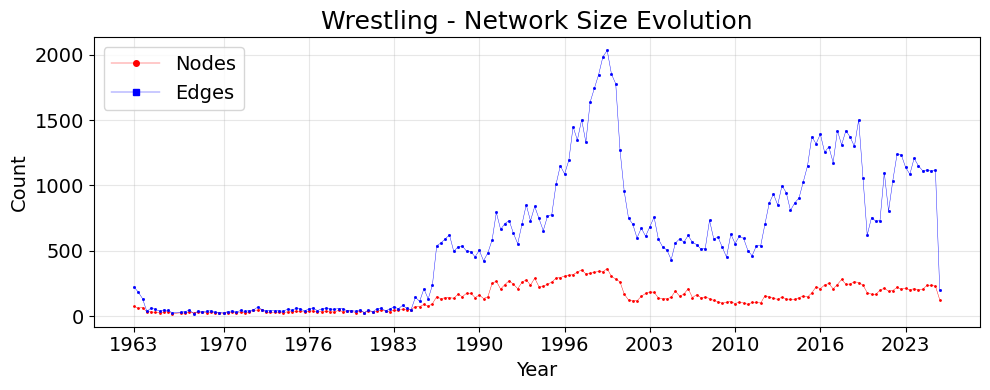

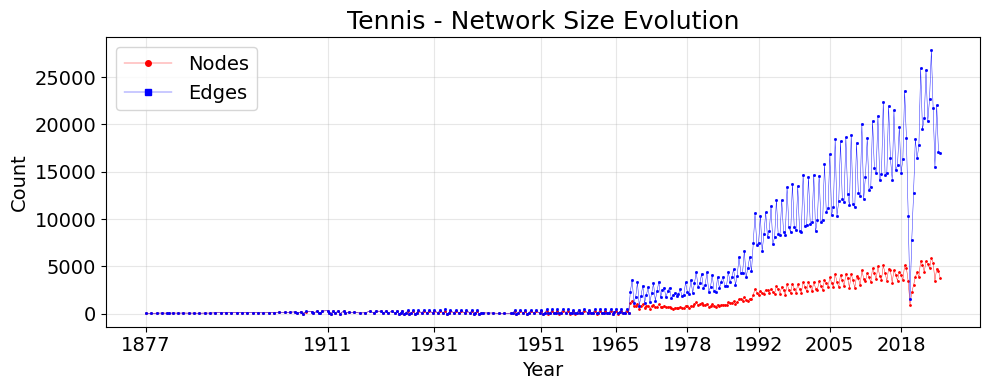

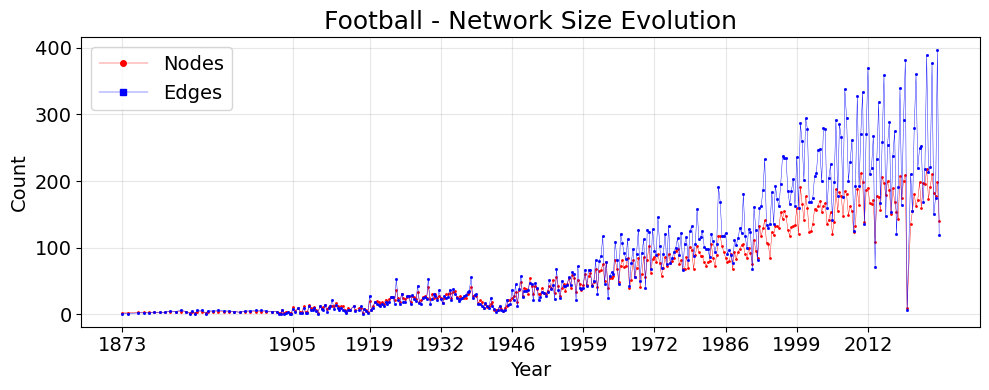

In [15]:
plot_network_size(wrestling_results, "Wrestling", tick_step=20)
plot_network_size(tennis_results, "Tennis", tick_step=40)
plot_network_size(football_results, "Football", tick_step=40)

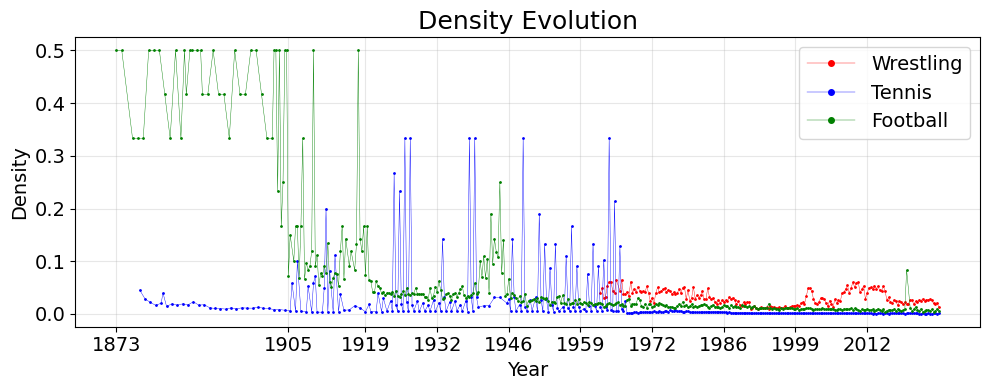

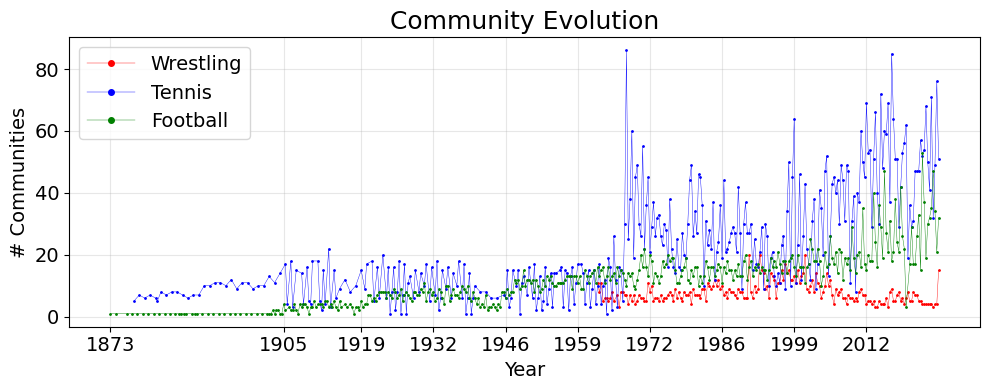

In [16]:
plot_density_comparison(wrestling_results, tennis_results, football_results)
plot_communities_comparison(wrestling_results, tennis_results, football_results)

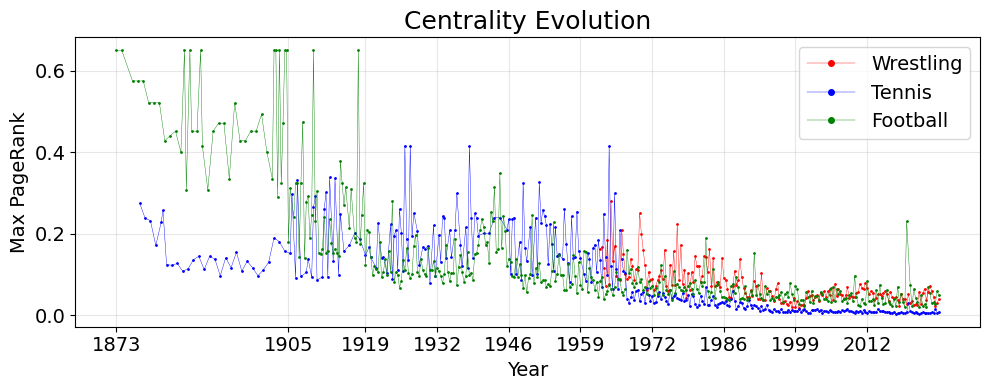

In [17]:
plot_centrality_comparison(wrestling_results, tennis_results, football_results)

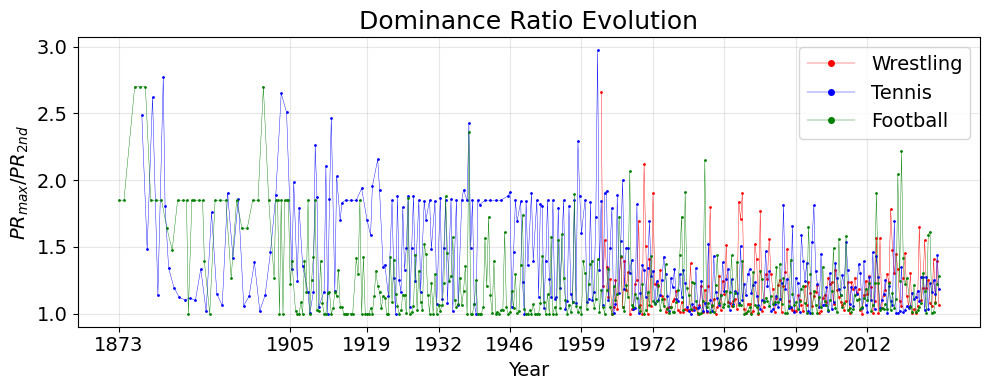

In [18]:
plot_dominance_ratio_comparison(wrestling_results, tennis_results, football_results)

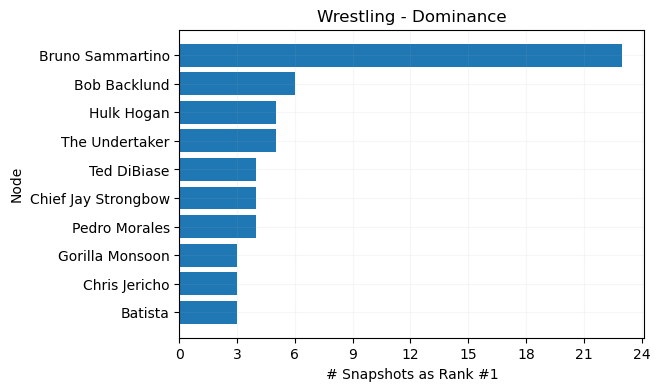

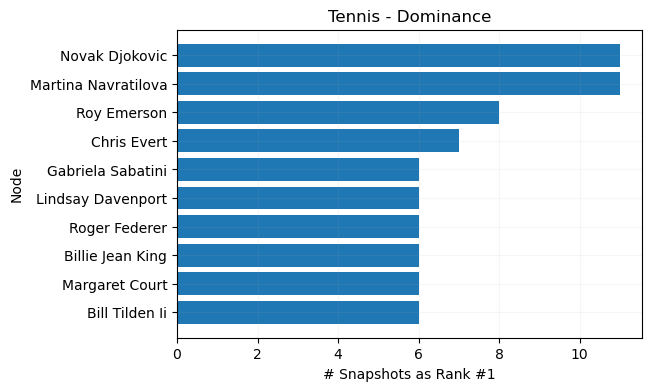

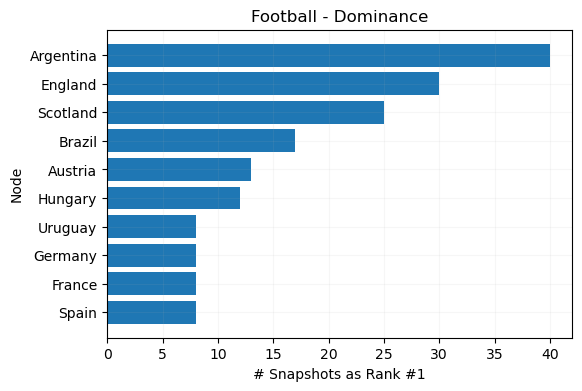

In [19]:
plot_dominance_hall_of_fame(wrestling_results, "Wrestling", top_n=10)
plot_dominance_hall_of_fame(tennis_results, "Tennis", top_n=10)
plot_dominance_hall_of_fame(football_results, "Football", top_n=10)

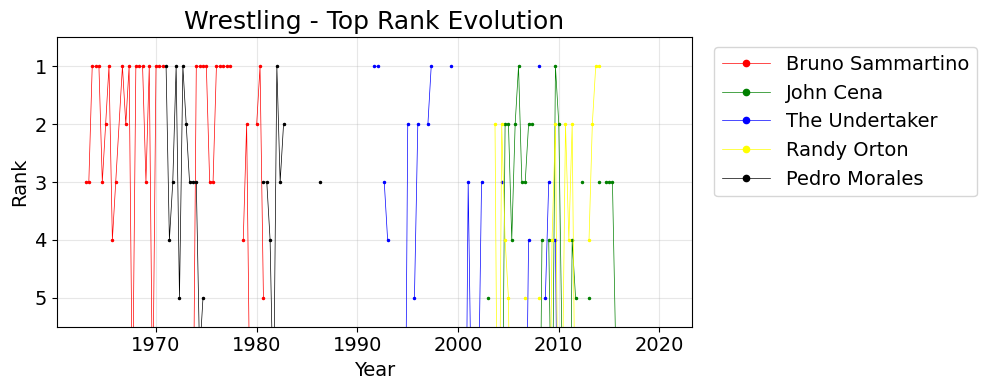

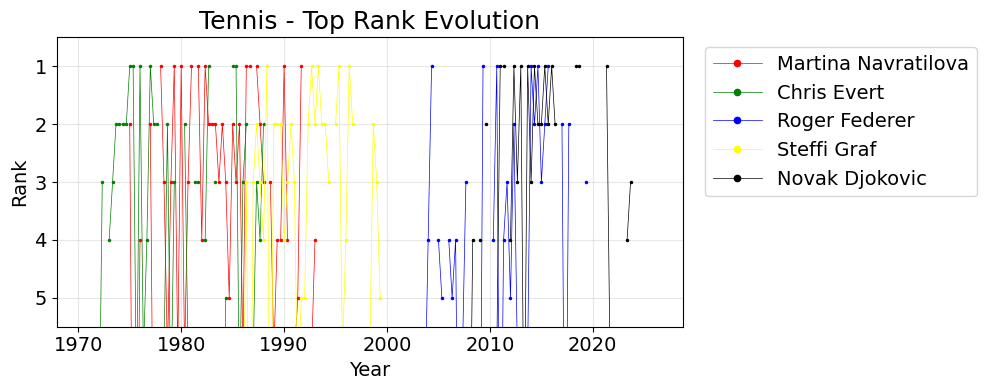

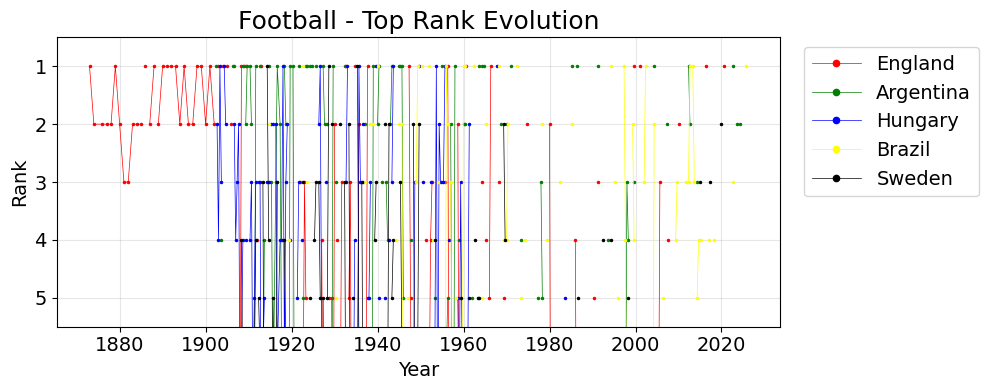

In [20]:
plot_rank_evolution(wrestling_results, "Wrestling", top_n_nodes=5)
plot_rank_evolution(tennis_results, "Tennis", top_n_nodes=5)
plot_rank_evolution(football_results, "Football", top_n_nodes=5)

### Layer plots

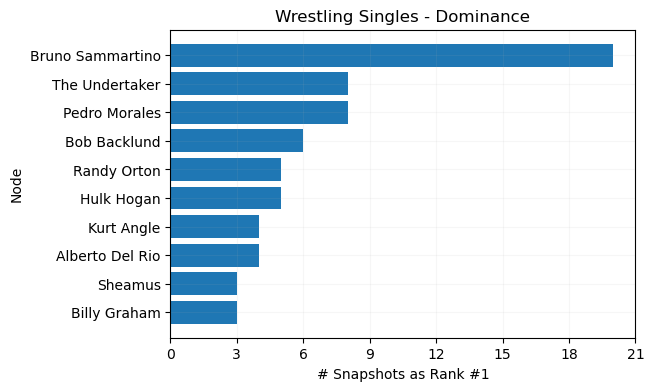

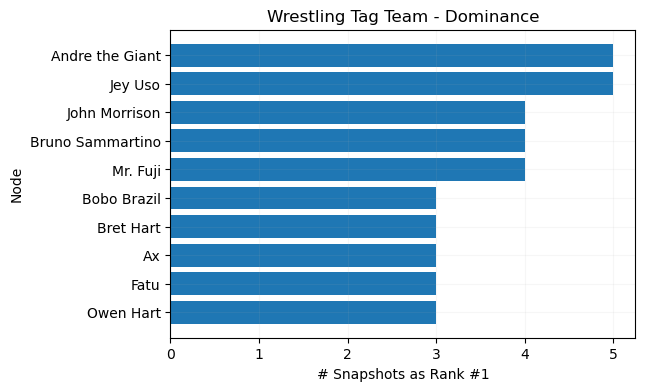

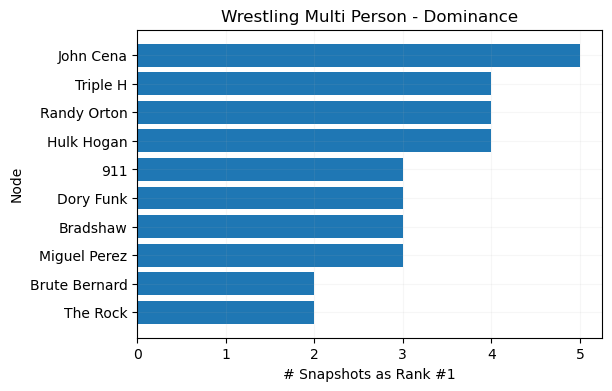

In [21]:
plot_dominance_hall_of_fame(wrestling_layers["singles"], "Wrestling Singles", top_n=10)
plot_dominance_hall_of_fame(wrestling_layers["tag_team"], "Wrestling Tag Team", top_n=10)
plot_dominance_hall_of_fame(wrestling_layers["multi_person"], "Wrestling Multi Person", top_n=10)

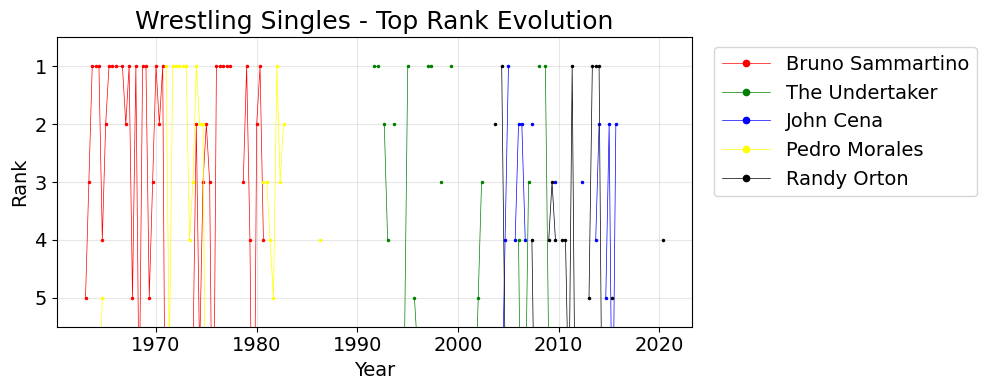

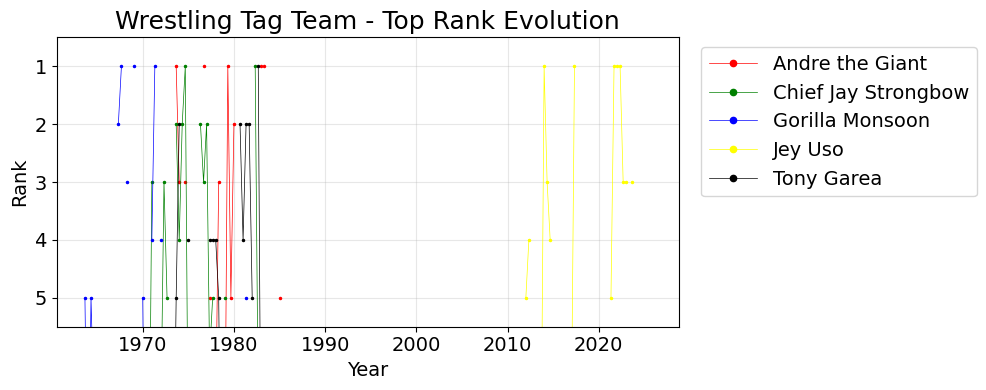

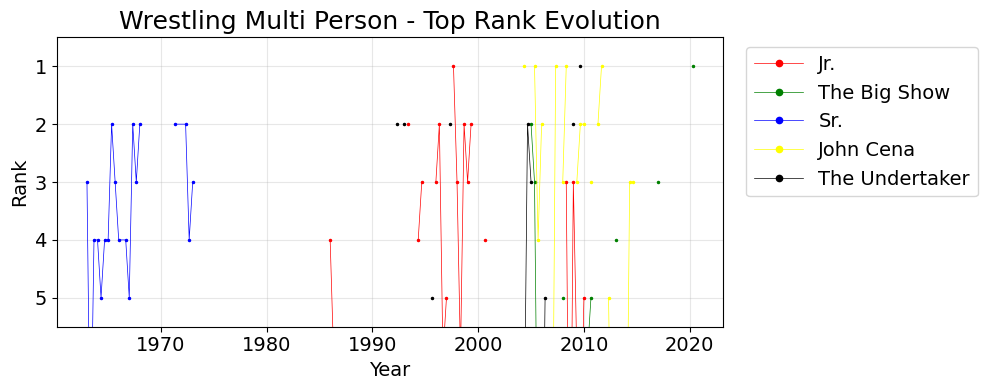

In [22]:
plot_rank_evolution(wrestling_layers["singles"], "Wrestling Singles", top_n_nodes=5)
plot_rank_evolution(wrestling_layers["tag_team"], "Wrestling Tag Team", top_n_nodes=5)
plot_rank_evolution(wrestling_layers["multi_person"], "Wrestling Multi Person", top_n_nodes=5)

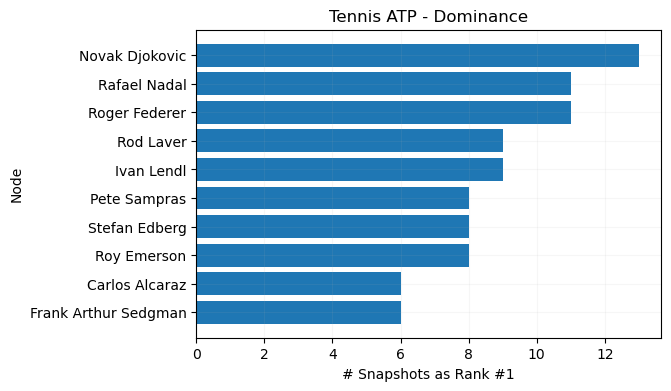

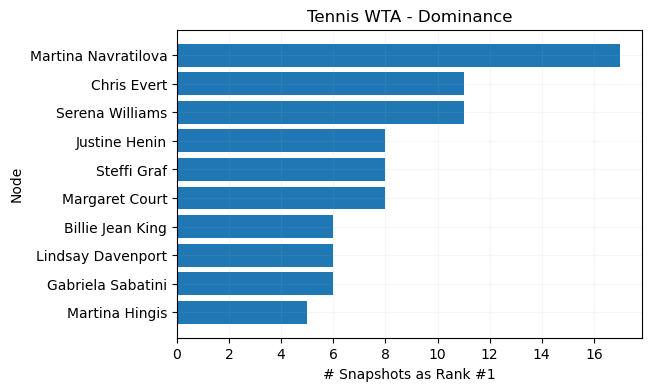

In [23]:
plot_dominance_hall_of_fame(tennis_tours["ATP"], "Tennis ATP", top_n=10)
plot_dominance_hall_of_fame(tennis_tours["WTA"], "Tennis WTA", top_n=10)

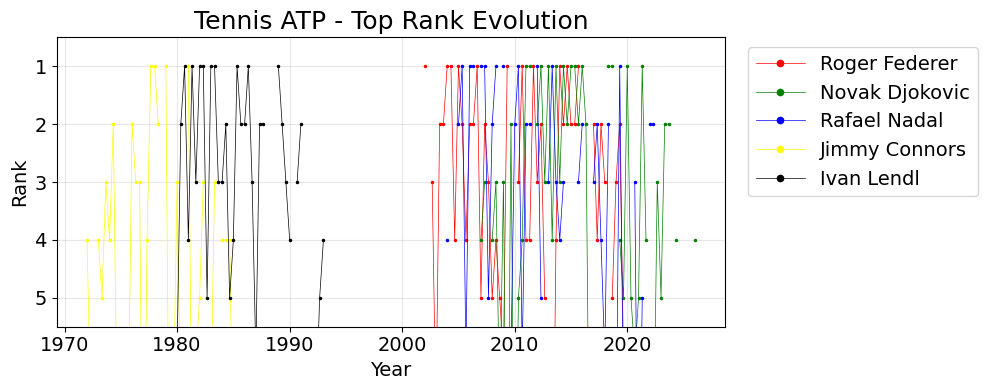

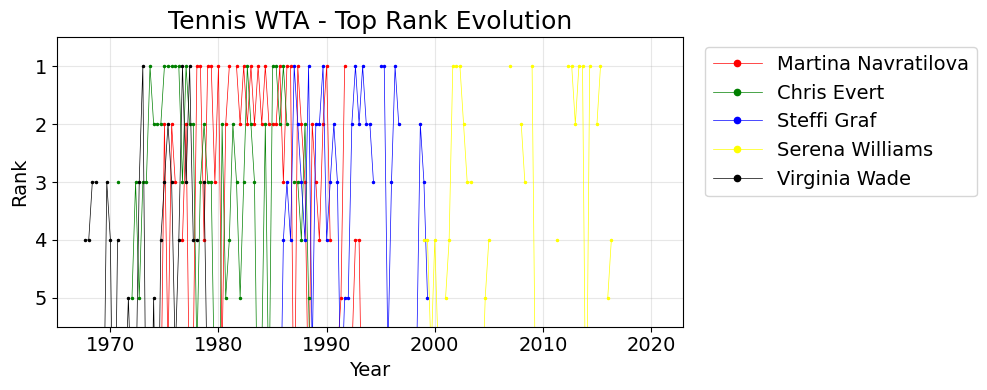

In [24]:
plot_rank_evolution(tennis_tours["ATP"], "Tennis ATP", top_n_nodes=5)
plot_rank_evolution(tennis_tours["WTA"], "Tennis WTA", top_n_nodes=5)

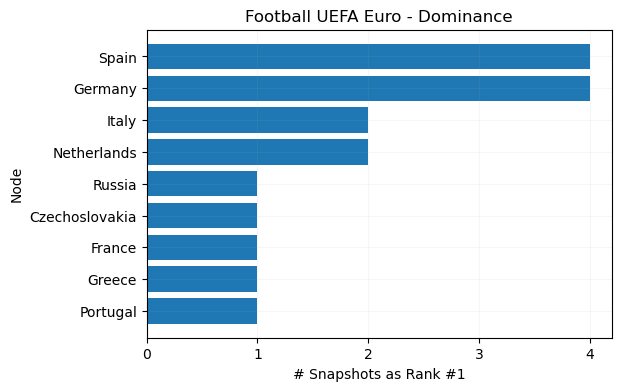

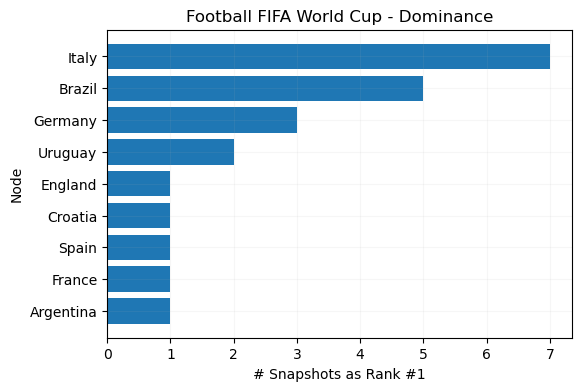

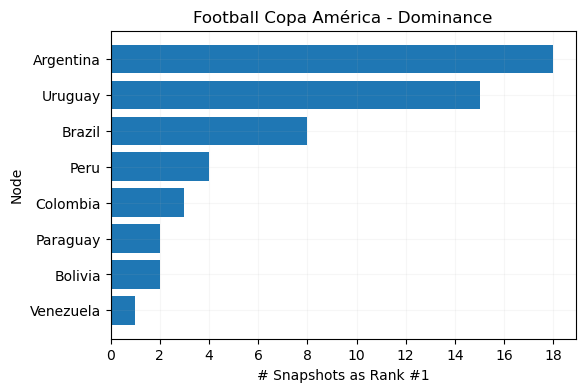

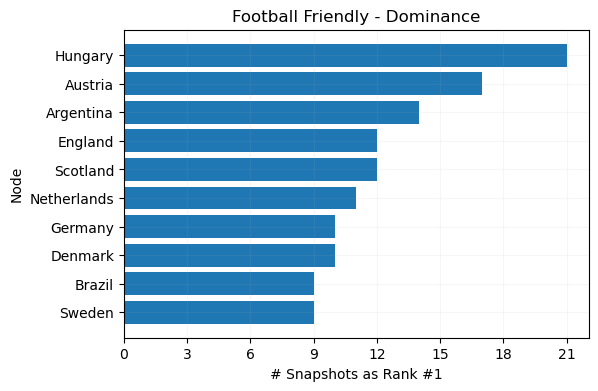

In [25]:
plot_dominance_hall_of_fame(football_tournaments["UEFA_Euro"], "Football UEFA Euro", top_n=10)
plot_dominance_hall_of_fame(football_tournaments["FIFA_World_Cup"], "Football FIFA World Cup", top_n=10)
plot_dominance_hall_of_fame(football_tournaments["Copa_América"], "Football Copa América", top_n=10)
plot_dominance_hall_of_fame(football_tournaments["Friendly"], "Football Friendly", top_n=10)

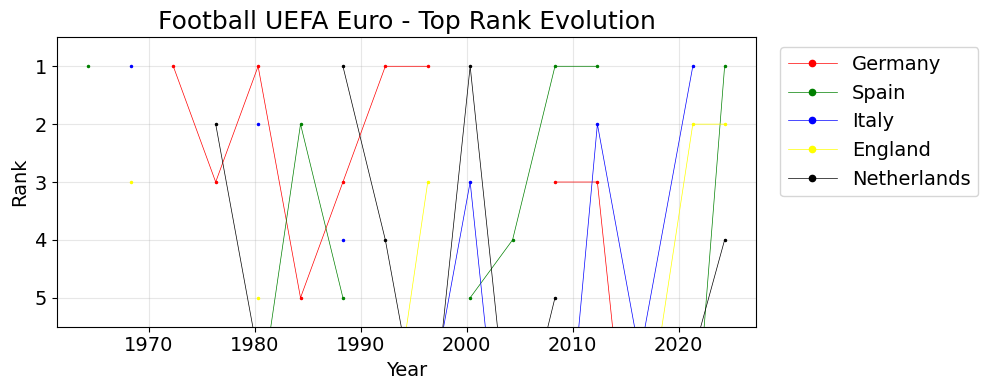

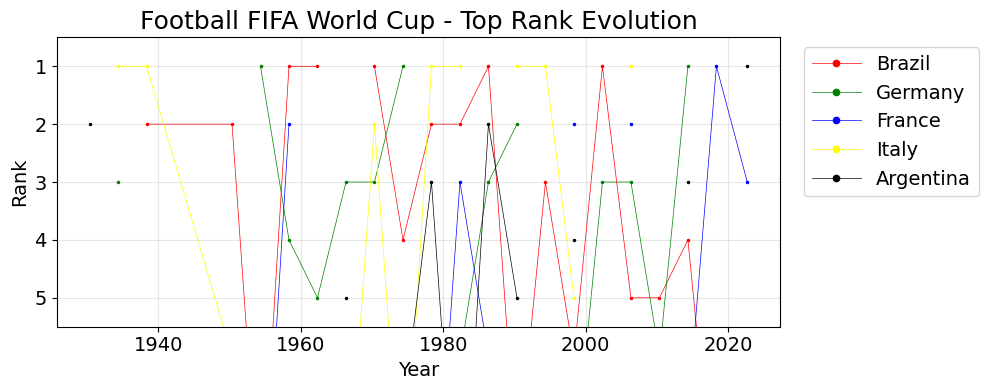

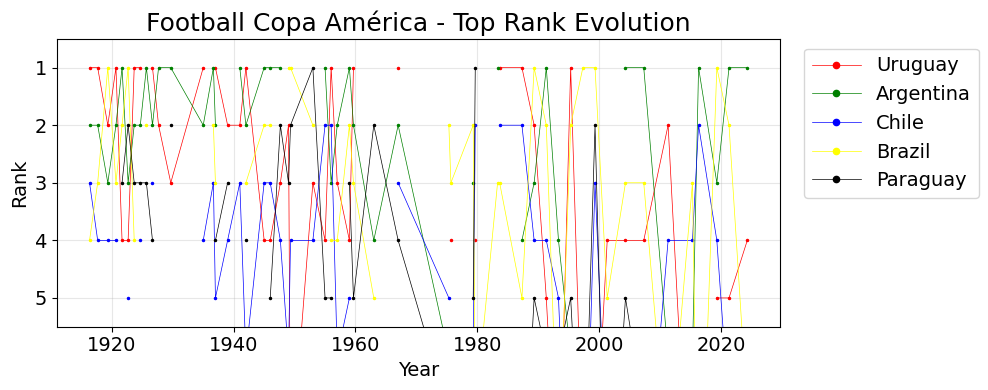

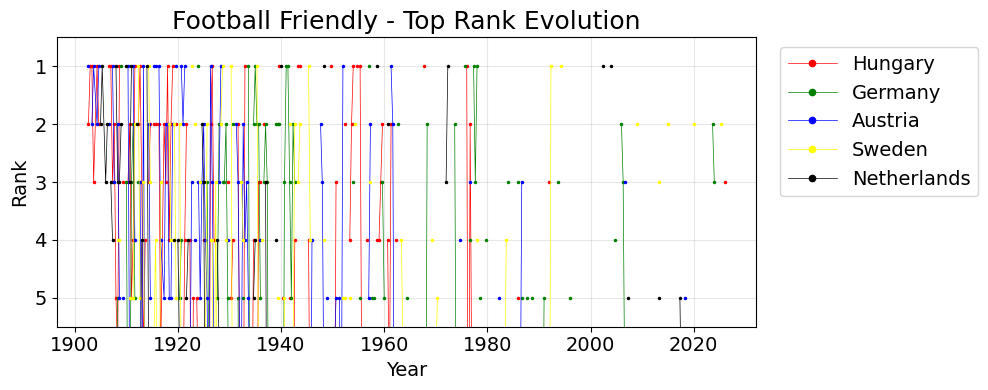

In [26]:
plot_rank_evolution(football_tournaments["UEFA_Euro"], "Football UEFA Euro", top_n_nodes=5)
plot_rank_evolution(football_tournaments["FIFA_World_Cup"], "Football FIFA World Cup", top_n_nodes=5)
plot_rank_evolution(football_tournaments["Copa_América"], "Football Copa América", top_n_nodes=5)
plot_rank_evolution(football_tournaments["Friendly"], "Football Friendly", top_n_nodes=5)